In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats

In [2]:
# Chargement et préparation des données
df = pd.read_excel("features_FW.xlsx")
print(df.shape)
df.head()

(1781, 75)


,Player,Nation,Pos,Team,Comp,Age,MP,Starts,Min,90s,...,Sh,Pass,Int,Tkl+Int,Clr,Err,Gls - xG,Sh/90,KP/90,Ligue_Weight
0,Matthis Abline,FRA,FW,Auxerre,Ligue 1,19,19,8,806,9.0,...,1,5,1,5,1,0,-1.6,0.111111,0.555556,1.1
1,Matthis Abline,FRA,FW,Rennes,Ligue 1,19,11,0,107,1.2,...,0,1,2,3,1,0,0.2,0.000000,1.666667,1.1
2,Zakaria Aboukhlal,MAR,FW,Toulouse,Ligue 1,22,37,28,2473,27.5,...,1,17,22,55,23,0,-1.5,0.036364,0.800000,1.1
3,Tammy Abraham,ENG,FW,Roma,Serie A,24,38,24,2189,24.3,...,4,6,3,20,14,0,-2.8,0.164609,1.358025,1.2
4,Che Adams,SCO,FW,Southampton,Premier League,26,28,23,1992,22.1,...,4,9,4,21,22,0,-1.7,0.180995,1.085973,1.5


In [3]:
#Séparer les variables descriptives (l'ACP n'utilise que les variables quantitatives)
meta_cols = [
    "Player", "Nation", "Pos", "Team", "Comp", "Year"
]

In [4]:
# Nettoyage : remplacer les virgules par des points
df= df.replace(",", ".", regex=True)
df = df.apply(pd.to_numeric, errors="ignore")

C:\Users\Aref Bakali\AppData\Local\Temp\ipykernel_19964\1306616843.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [5]:
# Sélection des features pour l'ACP
features_att = [
    "Gls/90", "xG/90","Ast/90", "KP", "G-PK/90",
    "PrgC", "PrgR", "PrgP"
]
X = df[features_att]
X.describe()


,Gls/90,xG/90,Ast/90,KP,G-PK/90,PrgC,PrgR,PrgP
count,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000
mean,0.293859,0.316705,0.133088,17.743403,0.269635,34.211117,97.775407,35.679394
std,0.241849,0.189153,0.151788,16.002453,0.227504,35.289211,77.809874,34.086439
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.121951,0.185185,0.000000,6.000000,0.110000,9.000000,36.000000,11.000000
50%,0.264901,0.285714,0.100000,13.000000,0.240000,22.000000,79.000000,25.000000
75%,0.416667,0.407534,0.200000,25.000000,0.380000,48.000000,139.000000,51.000000
max,1.818182,1.545455,1.700000,99.000000,1.820000,221.000000,520.000000,300.000000


In [6]:
df_clean = df.loc[df[features_att].dropna().index]
X = df_clean[features_att]

print(f"\nNombre de joueurs après nettoyage: {len(df_clean)}")
print(f"\nValeurs manquantes:\n{X.isnull().sum()}")


Nombre de joueurs après nettoyage: 1781

Valeurs manquantes:
Gls/90     0
xG/90      0
Ast/90     0
KP         0
G-PK/90    0
PrgC       0
PrgR       0
PrgP       0
dtype: int64


In [7]:
# Standardisation et ACP
X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


In [8]:
# Variance expliquée
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var*100:.2f}%")
print(f"Cumul PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

PC1: 46.84%
PC2: 30.08%
PC3: 10.91%
PC4: 5.57%
PC5: 3.66%
Cumul PC1+PC2: 76.91%


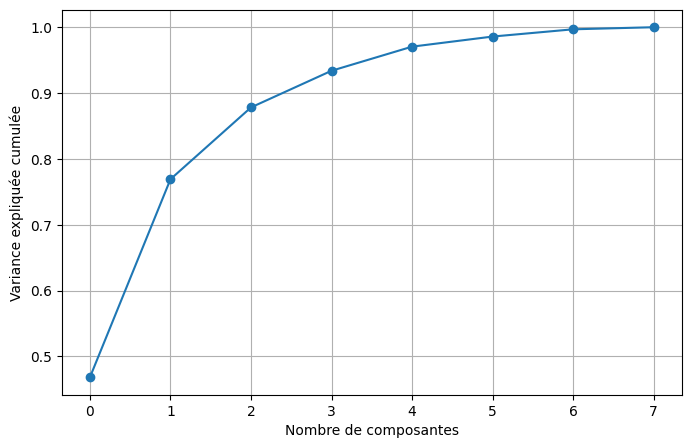

In [9]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.grid()
plt.show()


In [10]:
#Exploration des axes
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca2.components_.T,
    index=features_att,
    columns=["PC1", "PC2"]
)

print("\nCONTRIBUTIONS PC1")
print(loadings.sort_values("PC1", ascending=False))

print("\nCONTRIBUTIONS PC2")
print(loadings.sort_values("PC2", ascending=False))


CONTRIBUTIONS PC1
              PC1       PC2
KP       0.475759 -0.144376
PrgR     0.475175 -0.125060
PrgP     0.455374 -0.149715
PrgC     0.443581 -0.205131
Ast/90   0.214005 -0.023628
Gls/90   0.212743  0.567860
G-PK/90  0.193940  0.560967
xG/90    0.122726  0.511190

CONTRIBUTIONS PC2
              PC1       PC2
Gls/90   0.212743  0.567860
G-PK/90  0.193940  0.560967
xG/90    0.122726  0.511190
Ast/90   0.214005 -0.023628
PrgR     0.475175 -0.125060
KP       0.475759 -0.144376
PrgP     0.455374 -0.149715
PrgC     0.443581 -0.205131


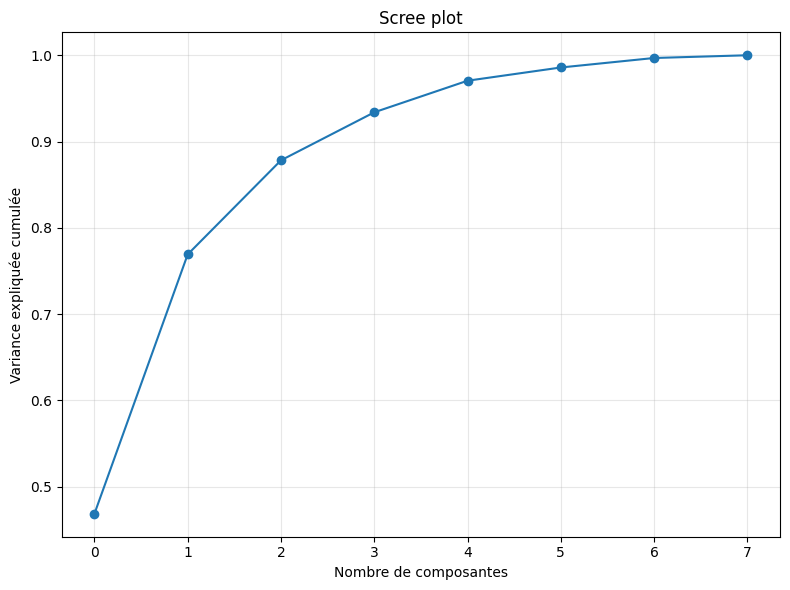

In [11]:
#Variance expliquée cumulée
plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Scree plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 2000x1500 with 0 Axes>

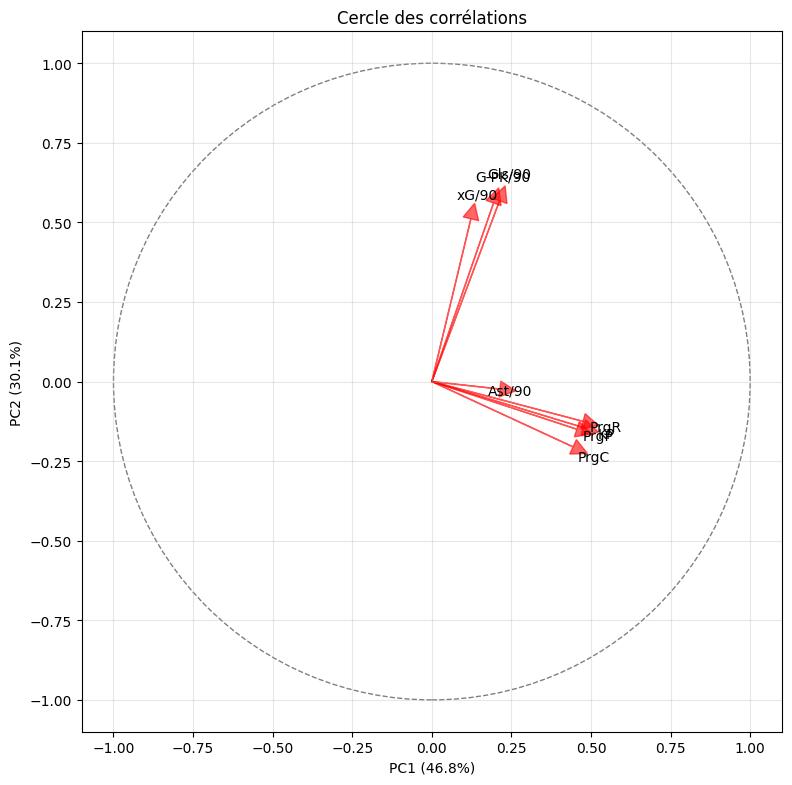

In [12]:
#Cercle des correlations
plt.figure(figsize=(20,15))
circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
fig, ax2 = plt.subplots(figsize=(8,8))
ax2.add_artist(circle)

for i, var in enumerate(features_att):
    ax2.arrow(0, 0, 
             loadings.iloc[i, 0], 
             loadings.iloc[i, 1],
             head_width=0.05, 
             head_length=0.05, 
             fc='red', 
             ec='red',
             alpha=0.6)
    ax2.text(loadings.iloc[i, 0]*1.15, 
            loadings.iloc[i, 1]*1.15, 
            var, 
            ha='center', 
            va='center',
            fontsize=10)

ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('Cercle des corrélations')
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

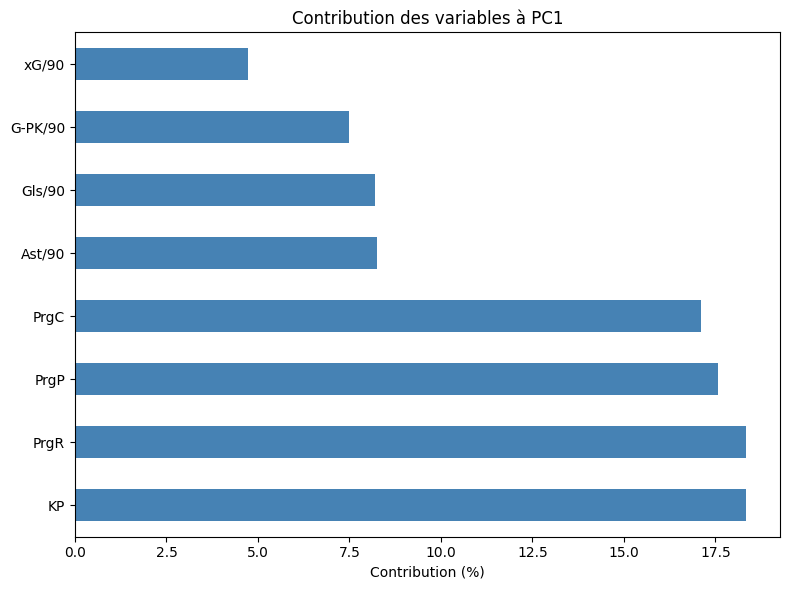

In [13]:
plt.figure(figsize=(8,6))
contrib = loadings.abs() * 100 / loadings.abs().sum()
contrib['PC1'].sort_values(ascending=False).plot(kind='barh', color='steelblue')
plt.title('Contribution des variables à PC1')
plt.xlabel('Contribution (%)')
plt.tight_layout()
plt.show()

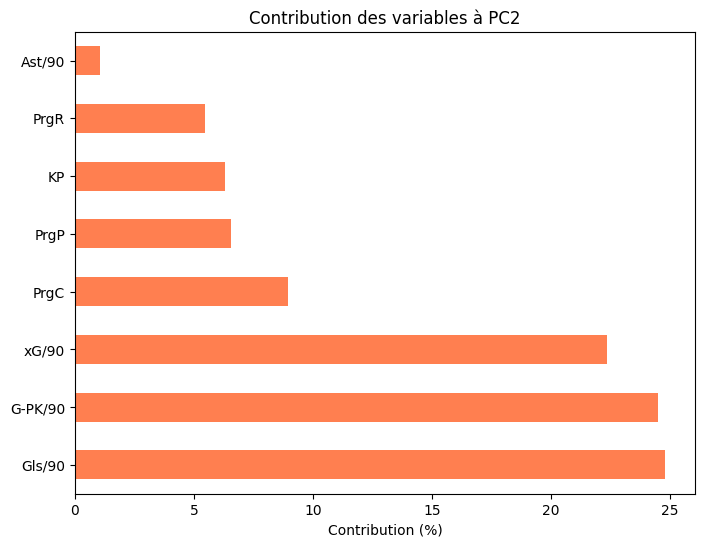

In [14]:
# 4.4 Contributions à PC2
plt.figure(figsize=(8,6))
contrib['PC2'].sort_values(ascending=False).plot(kind='barh', color='coral')
plt.title('Contribution des variables à PC2')
plt.xlabel('Contribution (%)')
plt.show()


In [15]:
df_pca = pd.DataFrame(X_pca2, columns=["PC1", "PC2"], index=df_clean.index)
df_results = df_clean.copy()
df_results["PC1"] = df_pca["PC1"]
df_results["PC2"] = df_pca["PC2"]

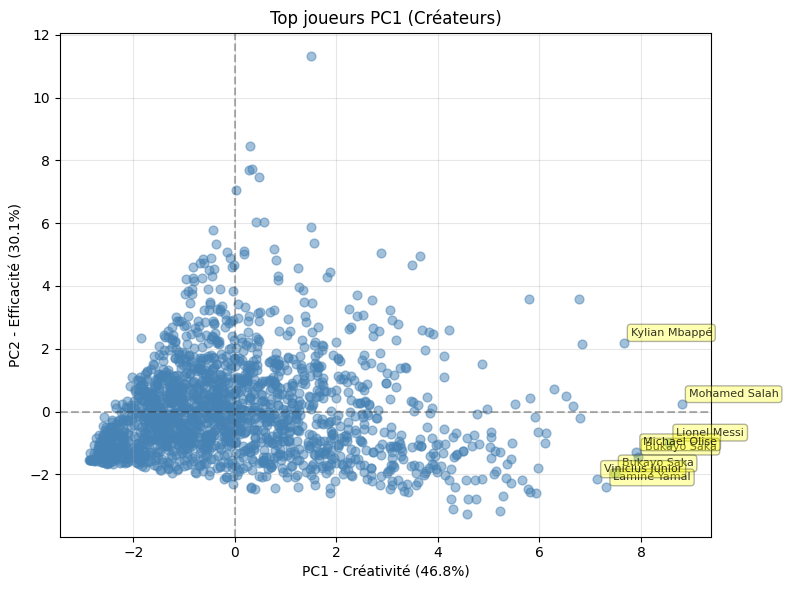

In [16]:
#Biplot top joueurs PC1
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                     alpha=0.5, s=40, c='steelblue')

top_players = df_results.nlargest(8, 'PC1')
for idx, row in top_players.iterrows():
    plt.annotate(row['Player'], 
                 (row['PC1'], row['PC2']),
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=8,
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

plt.xlabel(f'PC1 - Créativité ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 - Efficacité ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Top joueurs PC1 (Créateurs)')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

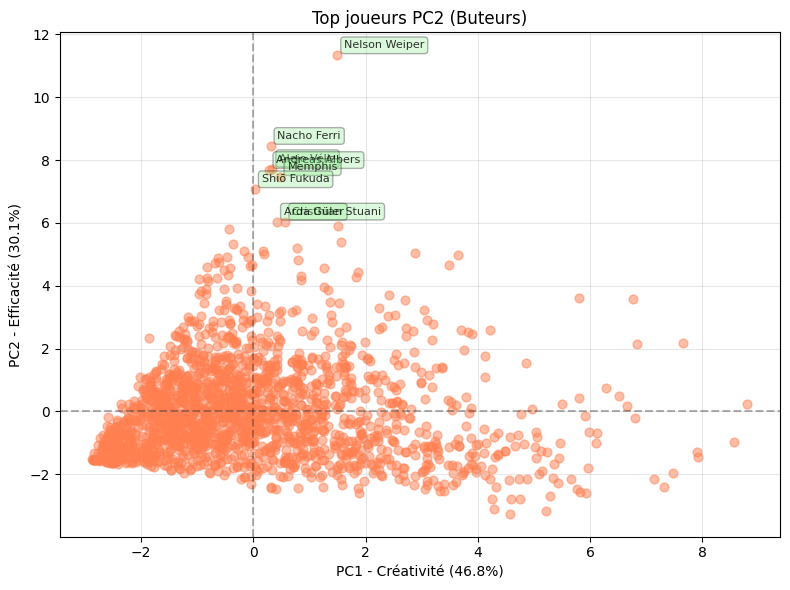

In [17]:
#Biplot top joueurs PC2
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                      alpha=0.5, s=40, c='coral')

top_scorers = df_results.nlargest(8, 'PC2')
for idx, row in top_scorers.iterrows():
    plt.annotate(row['Player'], 
                 (row['PC1'], row['PC2']),
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=8,
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.3))

plt.xlabel(f'PC1 - Créativité ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 - Efficacité ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Top joueurs PC2 (Buteurs)')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

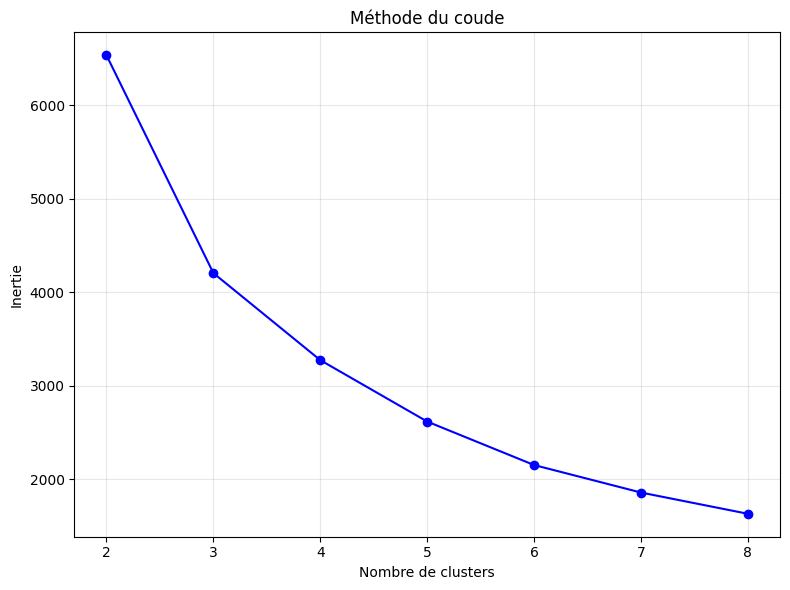

In [18]:
inertias = []
K_range = range(2, 9)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca2)
    inertias.append(kmeans.inertia_)


plt.figure(figsize=(8,6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

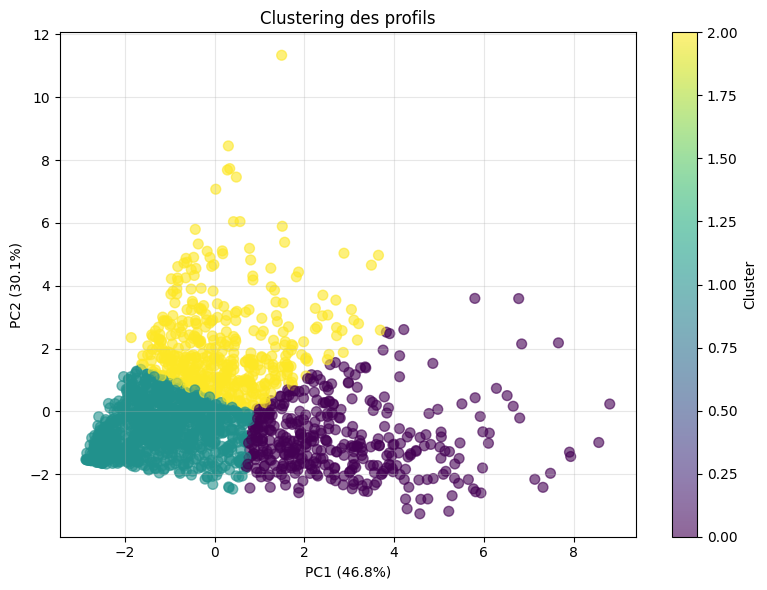

In [19]:
#Clustering K-means
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_results['Cluster'] = kmeans.fit_predict(X_pca2)

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                      c=df_results['Cluster'], 
                      cmap='viridis', 
                      alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Clustering des profils')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

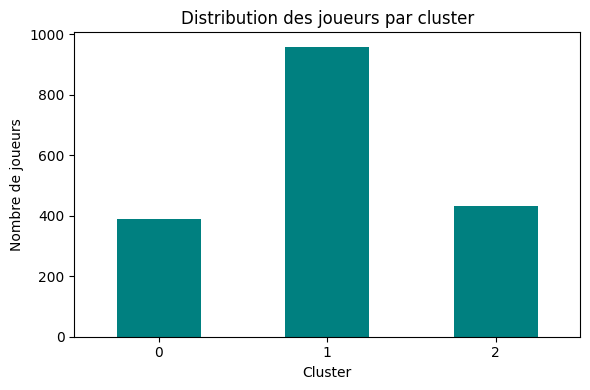

In [20]:
# Distribution des joueurs par cluster
plt.figure(figsize=(6,4))
df_results['Cluster'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Distribution des joueurs par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de joueurs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
print("\n🎯 CRÉATEURS (PC1 élevé, PC2 faible):")
creators = df_results[(df_results['PC1'] > df_results['PC1'].quantile(0.85)) & 
                      (df_results['PC2'] < df_results['PC2'].median())]
print(creators.nlargest(10,'PC1')[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())

print("\n⚽ BUTEURS PURS (PC2 élevé, PC1 faible):")
scorers = df_results[(df_results['PC2'] > df_results['PC2'].quantile(0.85)) & 
                     (df_results['PC1'] < df_results['PC1'].median())]
print(scorers.nlargest(10,'PC2')[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())

print("\n⭐ JOUEURS COMPLETS (PC1 et PC2 élevés):")
complete = df_results[(df_results['PC1'] > df_results['PC1'].quantile(0.90)) & 
                      (df_results['PC2'] > df_results['PC2'].quantile(0.90))]
print(complete[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())


🎯 CRÉATEURS (PC1 élevé, PC2 faible):
                 Player             Team            Comp       PC1       PC2
351        Lionel Messi        Paris S-G         Ligue 1  8.558722 -0.989878
1061        Bukayo Saka          Arsenal  Premier League  7.932644 -1.436345
1590      Michael Olise    Bayern Munich      Bundesliga  7.906270 -1.297846
468         Bukayo Saka          Arsenal  Premier League  7.482493 -1.970669
1764       Lamine Yamal        Barcelona         La Liga  7.316021 -2.417431
270     Vinicius Júnior      Real Madrid         La Liga  7.133848 -2.162206
212   Antoine Griezmann  Atlético Madrid         La Liga  6.120253 -0.692535
1528       Bryan Mbeumo        Brentford  Premier League  6.100865 -1.013758
822       Son Heung-min        Tottenham  Premier League  5.974818 -0.650300
1290       Rayan Cherki             Lyon         Ligue 1  5.968919 -1.801570

⚽ BUTEURS PURS (PC2 élevé, PC1 faible):
                 Player           Team            Comp       PC1       PC2

In [22]:
cluster_names = {
    0: "Type 0",
    1: "Type 1", 
    2: "Type 2"
}

for cluster in range(optimal_k):
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster} - {cluster_names[cluster]}")
    print(f"{'='*70}")
    
    cluster_data = df_results[df_results['Cluster'] == cluster]
    print(f"Nombre de joueurs: {len(cluster_data)}")
    
    print(f"\nTop 5 joueurs:")
    print(cluster_data.nlargest(5, 'PC1')[['Player', 'Team', 'PC1', 'PC2']].to_string())
    
    print(f"\nMoyennes des features:")
    means = cluster_data[features_att].mean()
    for feat, val in means.items():
        print(f"  {feat:15s}: {val:6.2f}")
    
    print(f"\nCaractéristiques PC:")
    print(f"  PC1 moyen: {cluster_data['PC1'].mean():6.2f} (créativité)")
    print(f"  PC2 moyen: {cluster_data['PC2'].mean():6.2f} (efficacité)")


CLUSTER 0 - Type 0
Nombre de joueurs: 391

Top 5 joueurs:
             Player           Team       PC1       PC2
1659  Mohamed Salah      Liverpool  8.803035  0.235108
351    Lionel Messi      Paris S-G  8.558722 -0.989878
1061    Bukayo Saka        Arsenal  7.932644 -1.436345
1590  Michael Olise  Bayern Munich  7.906270 -1.297846
346   Kylian Mbappé      Paris S-G  7.659913  2.181603

Moyennes des features:
  Gls/90         :   0.32
  xG/90          :   0.30
  Ast/90         :   0.21
  KP             :  40.56
  G-PK/90        :   0.28
  PrgC           :  85.96
  PrgR           : 206.10
  PrgP           :  82.82

Caractéristiques PC:
  PC1 moyen:   2.75 (créativité)
  PC2 moyen:  -0.86 (efficacité)

CLUSTER 1 - Type 1
Nombre de joueurs: 959

Top 5 joueurs:
             Player         Team       PC1       PC2
1325    Brahim Díaz  Real Madrid  0.778520 -0.292505
1267  Marius Bülter   Hoffenheim  0.765751 -0.200992
7        Amine Adli   Leverkusen  0.764307 -0.077456
1152  Wout Weghorst 